# Charge-charge response function and its RPA form
Let us see how the density of a chain responds to a potential that oscillates in space and in
time, with `h.get_chi()` and `h.get_densitychi_RPA()`. For non-interacting electrons the
response at momentum transfer $q$ and frequency $\omega$ is a sum over transitions from an
occupied state at $k$ to an empty one at $k+q$,
$$
\chi_0(q,\omega) = \sum_{k,n,m}
f(\epsilon_{k,n}) (1-f(\epsilon_{k+q,m}))
\frac{|\langle \Psi_{k,n}|\Psi_{k+q,m}\rangle|^2}
{\epsilon_{k,n} - \epsilon_{k+q,m} - \omega + i\delta}
$$
and its imaginary part is the particle-hole continuum, the energies that a scattering from $k$
to $k+q$ across the Fermi level can cost, which is what inelastic scattering of electrons or
X-rays measures. With a density-density interaction the potential also moves the charge that
produces it, and summing that series at the random phase approximation (RPA) level gives
$\chi_{RPA} = \chi_0(1-V\chi_0)^{-1}$. `h.get_densitychi_RPA()` takes the interaction directly
as an onsite `U` and neighbor-shell `V1`, `V2`, `V3` couplings, so no mean-field calculation is
needed first, and returns the response as a matrix over the sites of the unit cell.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### The particle-hole continuum of a chain
We take a spinful chain at half filling and scan the bare response over the momentum transfer.

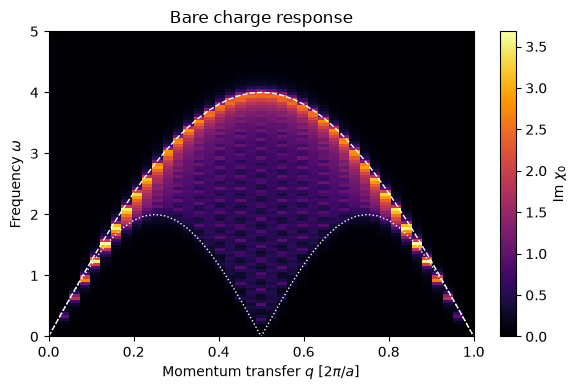

In [2]:
g = geometry.chain() # one-dimensional chain
h = g.get_hamiltonian(has_spin=True) # spinful Hamiltonian, half filling
es = np.linspace(0.,5.,100) # frequencies
qs = np.linspace(0.,1.,41) # momentum transfers over the Brillouin zone
chi0 = np.array([h.get_chi(q=[q,0.,0.],energies=es,nk=100,delta=0.05)[1] for q in qs])

plt.figure(figsize=(6,4))
plt.imshow(chi0.imag.T,origin="lower",aspect="auto",cmap="inferno",
           extent=[qs[0],qs[-1],es[0],es[-1]])
plt.colorbar(label=r"Im $\chi_0$")
plt.plot(qs,4*np.sin(np.pi*qs),c="white",ls="--",lw=1) # upper edge of the continuum
plt.plot(qs,2*np.abs(np.sin(2*np.pi*qs)),c="white",ls=":",lw=1) # lower edge of the continuum
plt.xlabel("Momentum transfer $q$ [$2\\pi/a$]") ; plt.ylabel(r"Frequency $\omega$")
plt.title("Bare charge response")
plt.tight_layout()
plt.show()

The weight fills the region between $\omega = 2t|\sin(qa)|$, the dotted line, and
$\omega = 4t\sin(qa/2)$, the dashed one, the smallest and the largest energy a particle-hole
pair of momentum $q$ can have in a half-filled cosine band. The continuum reaches zero frequency
only at $q=0$ and at $q=\pi/a$, twice the Fermi wavevector, where a pair can be made at no cost
by taking an electron from one Fermi point to the other: this is the nesting of the
one-dimensional Fermi surface.

### Dressing it with an interaction
We now add two different interactions to the same chain. An onsite Hubbard $U$ is a repulsion
that does not depend on $q$. A first-neighbor repulsion $V_1$ instead becomes
$V(q) = V_1\cos(qa)$ in reciprocal space, which is repulsive at small $q$ but attractive at the
zone boundary, exactly where the nesting of the Fermi surface makes the static bare response
large.

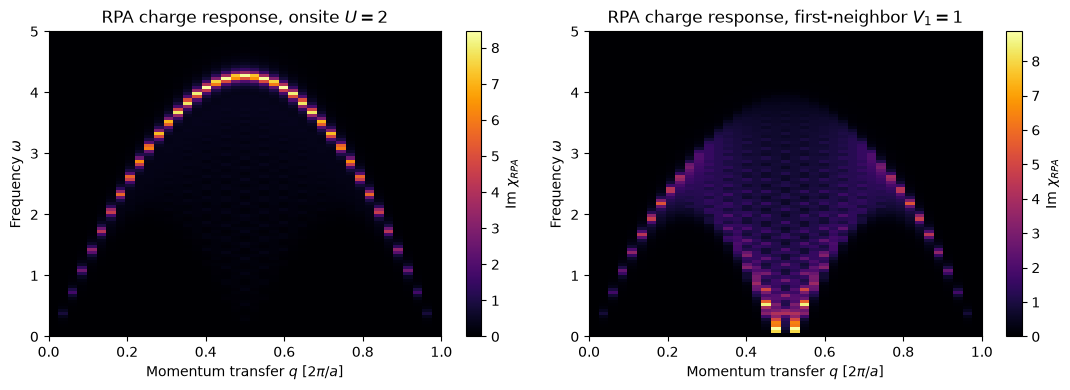

In [3]:
chiU = np.array([np.trace(h.get_densitychi_RPA(U=2.0,q=[q,0.,0.],energies=es,
                 nk=100,delta=0.05)[1],axis1=1,axis2=2) for q in qs]) # onsite U
chiV = np.array([np.trace(h.get_densitychi_RPA(V1=1.0,q=[q,0.,0.],energies=es,
                 nk=100,delta=0.05)[1],axis1=1,axis2=2) for q in qs]) # first neighbors

fig,axs = plt.subplots(1,2,figsize=(11,4))
for ax,chi,name in zip(axs,[chiU,chiV],["onsite $U=2$","first-neighbor $V_1=1$"]):
    im = ax.imshow(chi.imag.T,origin="lower",aspect="auto",cmap="inferno",
                   extent=[qs[0],qs[-1],es[0],es[-1]])
    fig.colorbar(im,ax=ax,label=r"Im $\chi_{RPA}$")
    ax.set_xlabel("Momentum transfer $q$ [$2\\pi/a$]") ; ax.set_ylabel(r"Frequency $\omega$")
    ax.set_title("RPA charge response, "+name)
plt.tight_layout()
plt.show()

The onsite repulsion pushes the weight to the top of the continuum at every $q$, where it piles
up into a sharp mode along the upper edge: a collective charge oscillation that costs more than
any single particle-hole pair. The first-neighbor repulsion does the same at small $q$, where
$V(q)$ is repulsive, but around $q=\pi/a$ it is attractive and pulls the weight down to zero
frequency instead. A soft mode at the nesting wavevector is the precursor of a
charge-density-wave instability: increasing $V_1$ further makes $1-V\chi_0$ vanish at zero
frequency, and the chain would rather double its unit cell and order.